# GridGuard AI — Dataset Exploration (01)

**Dataset:** Panama National Electricity Load — Mendeley Data, DOI [10.17632/byx7sztj59.1](https://data.mendeley.com/datasets/byx7sztj59/1)
**Author:** Ernesto Aguilar Madrid, 2021
**Primary file analyzed:** `ml/data/raw/continuous dataset.csv`

Scope: read-only validation and exploration. No modeling, no synthetic data, no preprocessing of the raw file in this notebook (a copy is loaded into memory; the raw CSV on disk is never written to).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

RAW_PATH = os.path.join("..", "data", "raw", "continuous dataset.csv")
FIG_DIR = os.path.join("..", "reports", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (12, 4)


Matplotlib is building the font cache; this may take a moment.


## 1. Load raw file and inspect shape / columns / dtypes

In [2]:
df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
df.dtypes


Shape: (48048, 17)


datetime          str
nat_demand    float64
T2M_toc       float64
QV2M_toc      float64
TQL_toc       float64
W2M_toc       float64
T2M_san       float64
QV2M_san      float64
TQL_san       float64
W2M_san       float64
T2M_dav       float64
QV2M_dav      float64
TQL_dav       float64
W2M_dav       float64
Holiday_ID      int64
holiday         int64
school          int64
dtype: object

In [3]:
df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


## 2. Parse datetime and check sampling frequency

In [4]:
df["datetime"] = pd.to_datetime(df["datetime"])
deltas = df["datetime"].diff().dropna()
print(deltas.value_counts())
print("Inferred frequency:", pd.infer_freq(df["datetime"]))
print("Min timestamp:", df["datetime"].min())
print("Max timestamp:", df["datetime"].max())


datetime
0 days 01:00:00    48047
Name: count, dtype: int64
Inferred frequency: h
Min timestamp: 2015-01-03 01:00:00
Max timestamp: 2020-06-27 00:00:00


## 3. Missing values per column

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(4)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
datetime,0,0.0
nat_demand,0,0.0
T2M_toc,0,0.0
QV2M_toc,0,0.0
TQL_toc,0,0.0
W2M_toc,0,0.0
T2M_san,0,0.0
QV2M_san,0,0.0
TQL_san,0,0.0
W2M_san,0,0.0


## 4. Duplicate rows / duplicate timestamps

In [6]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated timestamps:", df["datetime"].duplicated().sum())


Fully duplicated rows: 0
Duplicated timestamps: 0


## 5. Continuity check — are all expected hourly timestamps present?

In [7]:
full_range = pd.date_range(start=df["datetime"].min(), end=df["datetime"].max(), freq="h")
missing_ts = full_range.difference(df["datetime"])
print(f"Expected hourly timestamps: {len(full_range)}")
print(f"Actual rows: {len(df)}")
print(f"Gaps (missing timestamps): {len(missing_ts)}")


Expected hourly timestamps: 48048
Actual rows: 48048
Gaps (missing timestamps): 0


## 6. Descriptive statistics — load column (`nat_demand`)

In [8]:
df["nat_demand"].describe()

count    48048.000000
mean      1182.868647
std        192.068896
min         85.192500
25%       1020.056900
50%       1168.427700
75%       1327.563950
max       1754.882000
Name: nat_demand, dtype: float64

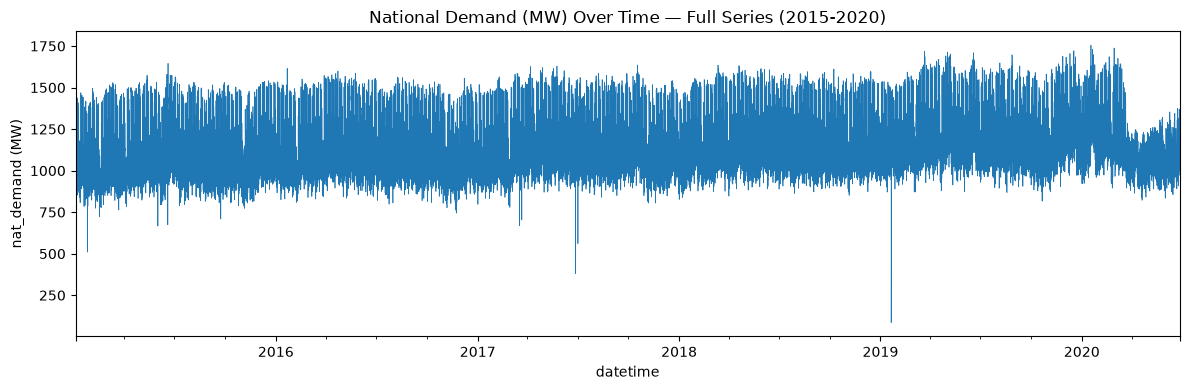

In [9]:
fig, ax = plt.subplots()
df.set_index("datetime")["nat_demand"].plot(ax=ax, linewidth=0.5)
ax.set_title("National Demand (MW) Over Time — Full Series (2015-2020)")
ax.set_ylabel("nat_demand (MW)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "load_over_time.png"), dpi=120)
plt.show()


## 7. Anomaly check — outliers and large jumps

In [10]:
q1, q3 = df["nat_demand"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 3*iqr, q3 + 3*iqr
outliers = df[(df["nat_demand"] < lower) | (df["nat_demand"] > upper)]
print(f"3xIQR fence: [{lower:.1f}, {upper:.1f}]")
print(f"Outlier rows: {len(outliers)}")
outliers[["datetime", "nat_demand"]]


3xIQR fence: [97.5, 2250.1]
Outlier rows: 1


,datetime,nat_demand
35483,2019-01-20 12:00:00,85.1925


In [11]:
jump = df["nat_demand"].diff().abs()
thresh = jump.quantile(0.999)
print("99.9th pct of |hour-to-hour change|:", round(thresh, 2))
df.loc[jump > thresh, ["datetime", "nat_demand"]].head(20)


99.9th pct of |hour-to-hour change|: 213.21


,datetime,nat_demand
520,2015-01-24 17:00:00,509.8358
521,2015-01-24 18:00:00,988.4130
895,2015-02-09 08:00:00,1210.6849
919,2015-02-10 08:00:00,1181.6389
1471,2015-03-05 08:00:00,1246.6374
1567,2015-03-09 08:00:00,1258.1496
1591,2015-03-10 08:00:00,1275.4709
1639,2015-03-12 08:00:00,1287.7142
1735,2015-03-16 08:00:00,1266.6678
1831,2015-03-20 08:00:00,1194.0404


## 8. Average load by hour of day

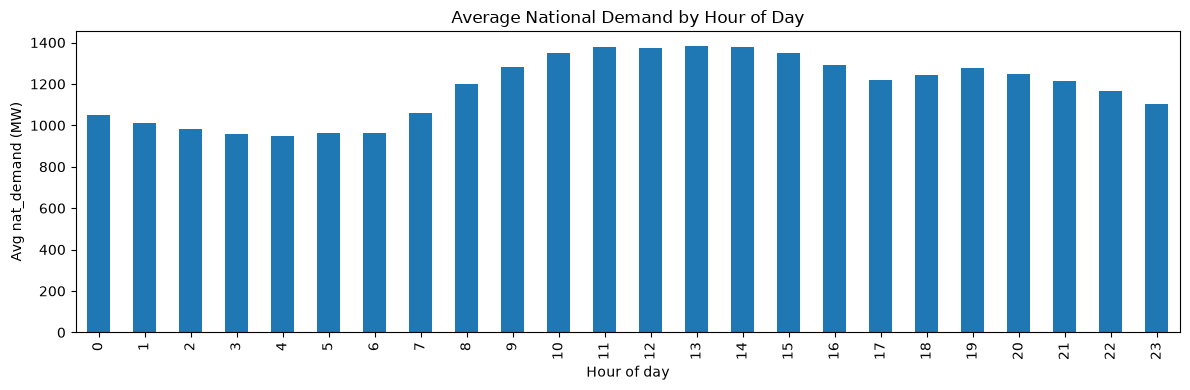

In [12]:
df["hour"] = df["datetime"].dt.hour
hourly_avg = df.groupby("hour")["nat_demand"].mean()

fig, ax = plt.subplots()
hourly_avg.plot(kind="bar", ax=ax)
ax.set_title("Average National Demand by Hour of Day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Avg nat_demand (MW)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "avg_load_by_hour.png"), dpi=120)
plt.show()


## 9. Average load by day of week

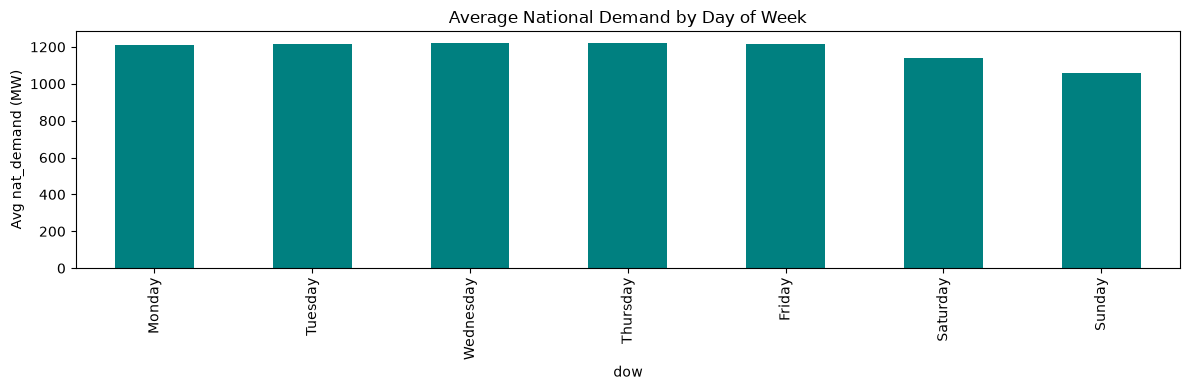

In [13]:
df["dow"] = df["datetime"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_avg = df.groupby("dow")["nat_demand"].mean().reindex(order)

fig, ax = plt.subplots()
dow_avg.plot(kind="bar", ax=ax, color="teal")
ax.set_title("Average National Demand by Day of Week")
ax.set_ylabel("Avg nat_demand (MW)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "avg_load_by_dow.png"), dpi=120)
plt.show()


## 10. Load distribution

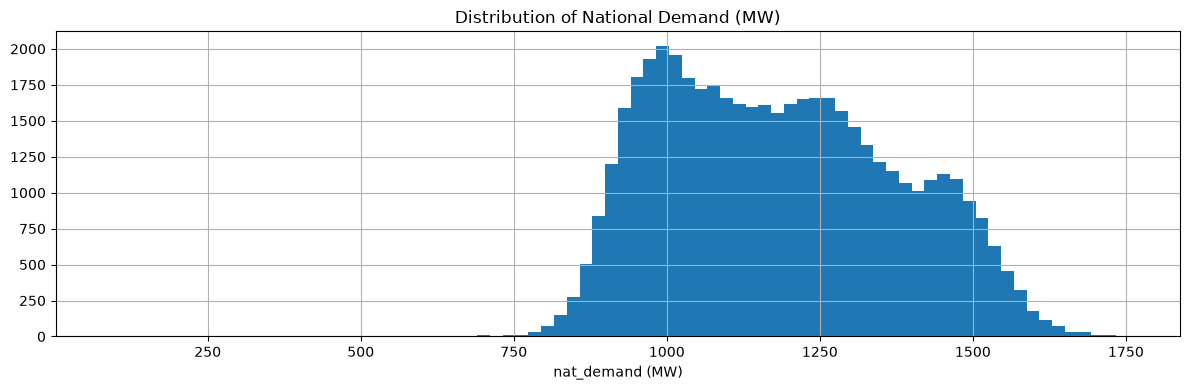

In [14]:
fig, ax = plt.subplots()
df["nat_demand"].hist(bins=80, ax=ax)
ax.set_title("Distribution of National Demand (MW)")
ax.set_xlabel("nat_demand (MW)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "load_distribution.png"), dpi=120)
plt.show()


## 11. Temperature vs. load (Tocumen station, `T2M_toc`)

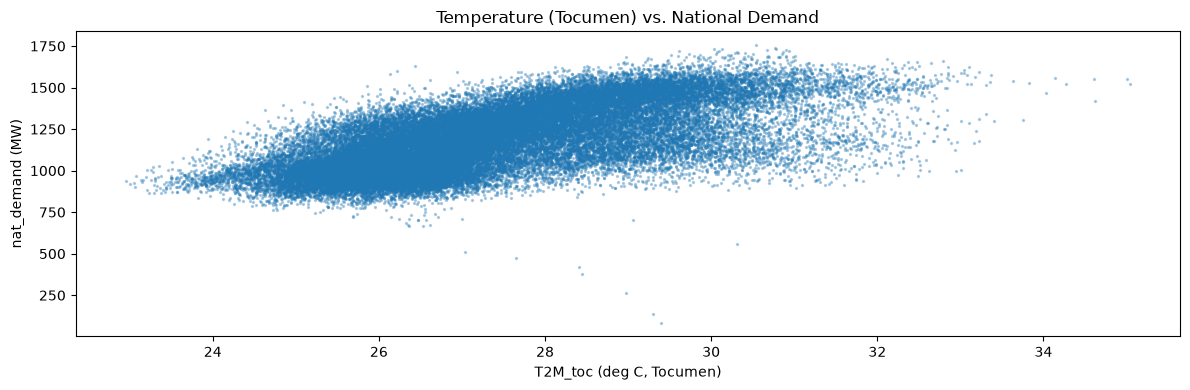

Correlation T2M_toc vs nat_demand: 0.653


In [15]:
fig, ax = plt.subplots()
ax.scatter(df["T2M_toc"], df["nat_demand"], s=2, alpha=0.3)
ax.set_xlabel("T2M_toc (deg C, Tocumen)")
ax.set_ylabel("nat_demand (MW)")
ax.set_title("Temperature (Tocumen) vs. National Demand")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "temp_vs_load.png"), dpi=120)
plt.show()

print("Correlation T2M_toc vs nat_demand:", df["T2M_toc"].corr(df["nat_demand"]).round(3))


## 12. Calendar variables — holiday and school flags

In [16]:
print(df["Holiday_ID"].value_counts().sort_index())
print()
print(df["holiday"].value_counts())
print()
print(df["school"].value_counts())


Holiday_ID
0     45024
1       144
2       144
3       144
4       144
5       144
6       144
7       144
8       144
9       144
10      144
11      144
12      168
13      120
14      120
15      120
16      144
17      120
18      120
19      144
20      120
21      144
22      120
Name: count, dtype: int64

holiday
0    45024
1     3024
Name: count, dtype: int64

school
1    34969
0    13079
Name: count, dtype: int64


## 13. Correlation matrix (numeric columns)

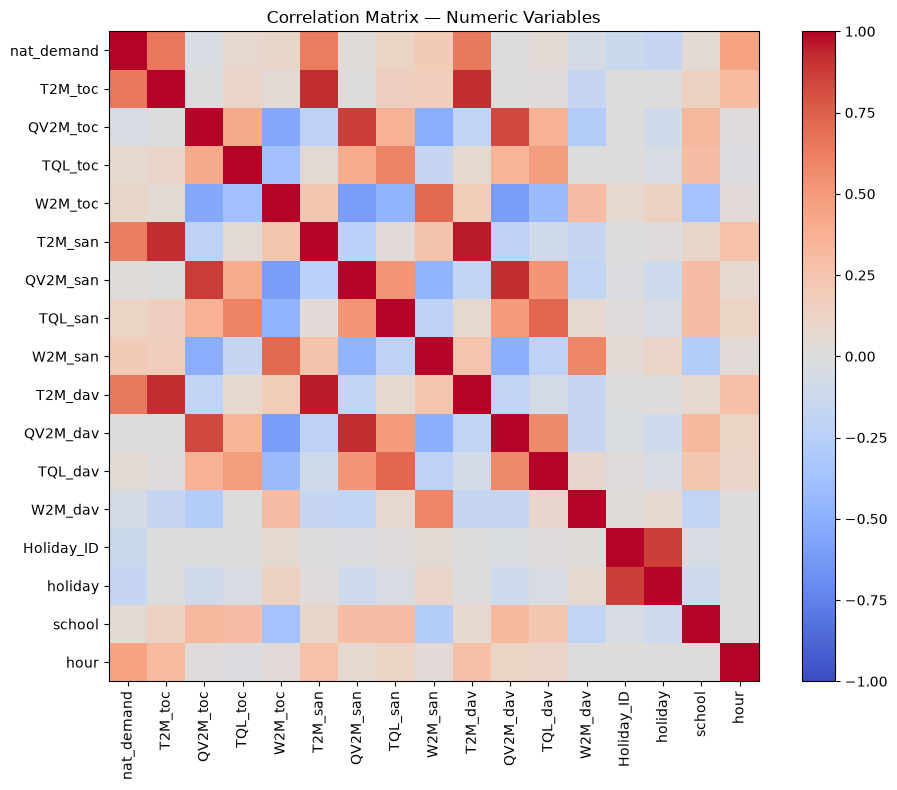

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school,hour
nat_demand,1.000000,0.652811,-0.036706,0.073109,0.098435,0.627024,0.022172,0.119038,0.191796,0.648279,-0.002117,0.042037,-0.054802,-1.298340e-01,-1.656735e-01,0.040044,4.530866e-01
T2M_toc,0.652811,1.000000,-0.012808,0.108872,0.051909,0.919992,0.006596,0.148560,0.169162,0.915632,-0.006409,0.012090,-0.158327,-8.897018e-03,-9.956757e-03,0.139053,3.050876e-01
QV2M_toc,-0.036706,-0.012808,1.000000,0.413594,-0.539345,-0.213480,0.867780,0.362050,-0.515202,-0.181143,0.833848,0.370708,-0.276294,-1.518191e-02,-9.708560e-02,0.329035,8.432573e-03
TQL_toc,0.073109,0.108872,0.413594,1.000000,-0.373020,0.042989,0.402671,0.606556,-0.153763,0.072130,0.343910,0.483151,-0.009188,6.687222e-03,-4.308324e-02,0.291893,-2.289693e-02
W2M_toc,0.098435,0.051909,-0.539345,-0.373020,1.000000,0.221042,-0.604814,-0.461718,0.703369,0.182972,-0.603195,-0.420152,0.292445,6.138006e-02,1.356263e-01,-0.363381,3.141099e-02
T2M_san,0.627024,0.919992,-0.213480,0.042989,0.221042,1.000000,-0.228587,0.036498,0.257591,0.960456,-0.217844,-0.099470,-0.156403,-6.452832e-03,1.489210e-02,0.100565,2.711686e-01
QV2M_san,0.022172,0.006596,0.867780,0.402671,-0.604814,-0.228587,1.000000,0.521369,-0.465553,-0.183251,0.921267,0.513204,-0.183522,-2.206729e-02,-1.045191e-01,0.290754,6.608193e-02
TQL_san,0.119038,0.148560,0.362050,0.606556,-0.461718,0.036498,0.521369,1.000000,-0.213468,0.066648,0.485120,0.723023,0.075153,8.381031e-03,-4.325679e-02,0.289251,1.182577e-01
W2M_san,0.191796,0.169162,-0.515202,-0.153763,0.703369,0.257591,-0.465553,-0.213468,1.000000,0.248129,-0.493433,-0.214795,0.585974,4.363705e-02,1.096224e-01,-0.277038,3.535884e-02
T2M_dav,0.648279,0.915632,-0.181143,0.072130,0.182972,0.960456,-0.183251,0.066648,0.248129,1.000000,-0.194773,-0.071277,-0.155059,-1.082625e-02,2.651578e-03,0.076727,2.787735e-01


In [17]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
fig.colorbar(im)
ax.set_title("Correlation Matrix — Numeric Variables")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "correlation_matrix.png"), dpi=120)
plt.show()

corr


## 14. Summary

See `ml/reports/dataset_audit.md` for the full written audit covering:
what the dataset contains, what's useful for forecasting, what's missing vs.
the GridGuard architecture, suitability, limitations, and next steps.
